1. Analyze and Preprocess data - Check if the dataset has missing values or has any other problem.
2. Feature Engineering
3. Divide the dataset into 2 training and test sets
4. Use logistic model Regression. Try to apply different *solver* and *penalty* to find the best one.
5. Perform model on training set and test set
6. Measure performance of the model.
7. Which metric is your main metric and why? Which solver and penalty have you chosen? (<= 100 words)


How can I measure your point:
1. Your function is callable and runs correctly
2. The performance of your model (in full pipeline) is acceptable. The final error based on my train and test set is low enough.
3. The data preprocessing is correct or make sense
4. The Feature engineering is correct or make sense
5. Any other additional process will be considered a small plus point.

**Submission Link**: https://forms.gle/M2CxqVGrKLTzqR7g9 (Submit your .ipynb file)

- Age: This is the attribute that describes the age of the patient. There is data type $int64$, the highest value is 29, and the lowest is 77.
- Sex: This is the attribute indicating the gender of the patient, where 0 indicates male patient, 1 female patient.
- ChestPainType: This is the attribute that indicates the patient's chest pain level. With levels 0, 1, 2, and 3.
- RestingBP: This is the attribute that indicates the patient's blood pressure with data type $int64$, the value is in the range [94, 200]
- Cholesterol: This attribute indicates the patient's cholesterol level as measured in the hospital. Has the data type $int64$, where the value is in [126, 564]
- FastingBS: This is an attribute that describes the patient's fasting blood sugar. In which, if the patient has more than 120mg/dl sugar = 1, otherwise = 0.
- RestingECG: This property displays the results of the ECG from 0 to 2 (0, 1, 2). Where each value indicates the severity of the pain.
- thalach: Patient's highest heart rate
- ExerciseAngina: Whether or not you have angina during exercise. Yes denotes 1, no denotes 0.
- Oldpeak: Attribute expressing the stress level of the patient. Has a value of type $float64$, the value is in [0, 6.2]
- ST\_Slope: Patient's condition during exercise. Includes [Upsloping, Flat, Down sloping] states that are sequentially digitized to [0, 1, 2].
- ca: number of major vessels (0-4) colored by flourosopy - given
- thal: 0 = normal; 1 = fixed defect; 2 = reversable defect
- HeartDisease: Results of the patient's condition. 1 is for signs of heart disease, 0 is for no signs of heart disease.

## Load Dataset

In [15]:
import pandas as pd
PATH = r"D:\Introduction-to-Machine-Learning_MTH10353\Homework\2\heart.csv"
df = pd.read_csv(PATH)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
1,71,0,1,160,302,0,1,162,0,0.4,2,2,2,1
2,71,0,1,160,303,0,1,163,0,0.4,2,2,2,1
3,71,0,1,160,304,0,1,164,0,0.4,2,2,2,1
4,71,0,1,160,305,0,1,165,0,0.4,2,2,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
881,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
882,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
883,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
884,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0


## Data Analysis

In [16]:
# Data analysis
# 1. Analyze and Preprocess data - Check if the dataset has missing values or has any other problem.

df.info()

print(df.describe())

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for invalid values (e.g., negative ages, unrealistic cholesterol levels)

# - Age: This is the attribute that describes the age of the patient. There is data type $int64$, the highest value is 29, and the lowest is 77.
# - Sex: This is the attribute indicating the gender of the patient, where 0 indicates male patient, 1 female patient.
# - ChestPainType: This is the attribute that indicates the patient's chest pain level. With levels 0, 1, 2, and 3.
# - RestingBP: This is the attribute that indicates the patient's blood pressure with data type $int64$, the value is in the range [94, 200]
# - Cholesterol: This attribute indicates the patient's cholesterol level as measured in the hospital. Has the data type $int64$, where the value is in [126, 564]
# - FastingBS: This is an attribute that describes the patient's fasting blood sugar. In which, if the patient has more than 120mg/dl sugar = 1, otherwise = 0.
# - RestingECG: This property displays the results of the ECG from 0 to 2 (0, 1, 2). Where each value indicates the severity of the pain.
# - thalach: Patient's highest heart rate
# - ExerciseAngina: Whether or not you have angina during exercise. Yes denotes 1, no denotes 0.
# - Oldpeak: Attribute expressing the stress level of the patient. Has a value of type $float64$, the value is in [0, 6.2]
# - ST\_Slope: Patient's condition during exercise. Includes [Upsloping, Flat, Down sloping] states that are sequentially digitized to [0, 1, 2].
# - ca: number of major vessels (0-4) colored by flourosopy - given
# - thal: 0 = normal; 1 = fixed defect; 2 = reversable defect
# - HeartDisease: Results of the patient's condition. 1 is for signs of heart disease, 0 is for no signs of heart disease.



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 886 entries, 0 to 885
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       886 non-null    int64  
 1   sex       886 non-null    int64  
 2   cp        886 non-null    int64  
 3   trestbps  886 non-null    int64  
 4   chol      886 non-null    int64  
 5   fbs       886 non-null    int64  
 6   restecg   886 non-null    int64  
 7   thalach   886 non-null    int64  
 8   exang     886 non-null    int64  
 9   oldpeak   886 non-null    float64
 10  slope     886 non-null    int64  
 11  ca        886 non-null    int64  
 12  thal      886 non-null    int64  
 13  target    886 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 97.0 KB
              age         sex          cp    trestbps        chol         fbs  \
count  886.000000  886.000000  886.000000  886.000000  886.000000  886.000000   
mean    54.007901    0.683973    1.005643  132.117381  24

Do dữ liệu cung cấp không có giá trị thiếu, chúng ta sẽ không cần phải xử lý giá trị thiếu. Tuy nhiên, chúng ta sẽ kiểm tra xem có bất kỳ giá trị nào bị lỗi hoặc không hợp lệ không.

In [20]:
print("Invalid values:")
print("Age: ", df[df["age"] < 0])
print("RestingBP: ", df[df["trestbps"] < 0])
print("Cholesterol: ", df[df["chol"] < 0])
print("Oldpeak: ", df[df["oldpeak"] < 0])
print("thal: ", df[~df["thal"].isin([0, 1, 2, 3])])
print("ca: ", df[~df["ca"].isin([0, 1, 2, 3, 4])])
print("ST_Slope: ", df[~df["slope"].isin([0, 1, 2])])
print("ChestPainType: ", df[~df["cp"].isin([0, 1, 2, 3])])
print("ExerciseAngina: ", df[~df["exang"].isin([0, 1])])
print("FastingBS: ", df[~df["fbs"].isin([0, 1])])
print("RestingECG: ", df[~df["restecg"].isin([0, 1, 2])])
print("HeartDisease: ", df[~df["target"].isin([0, 1])])


Invalid values:
Age:  Empty DataFrame
Columns: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target]
Index: []
RestingBP:  Empty DataFrame
Columns: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target]
Index: []
Cholesterol:  Empty DataFrame
Columns: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target]
Index: []
Oldpeak:  Empty DataFrame
Columns: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target]
Index: []
thal:  Empty DataFrame
Columns: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target]
Index: []
ca:  Empty DataFrame
Columns: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target]
Index: []
ST_Slope:  Empty DataFrame
Columns: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target]
Index: []
ChestPain

Như vậy không có giá trị nào bị lỗi hoặc không hợp lệ trong dữ liệu.

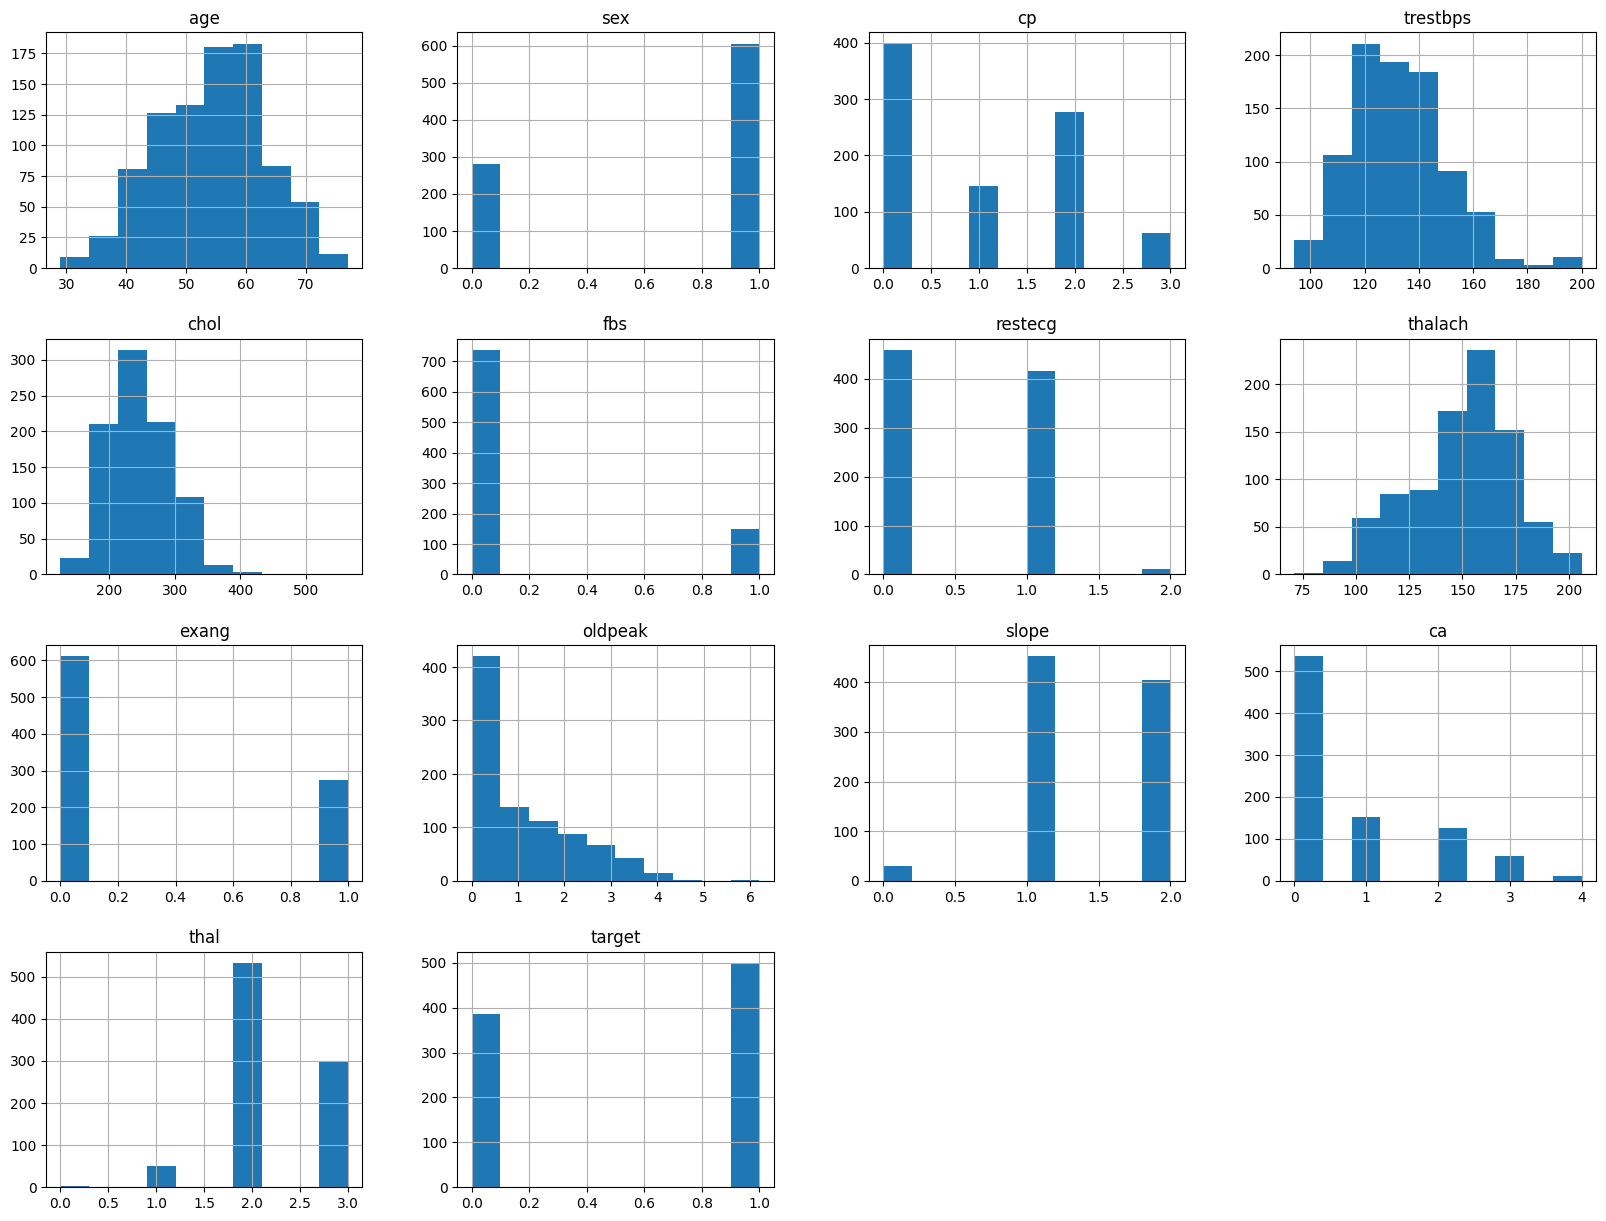

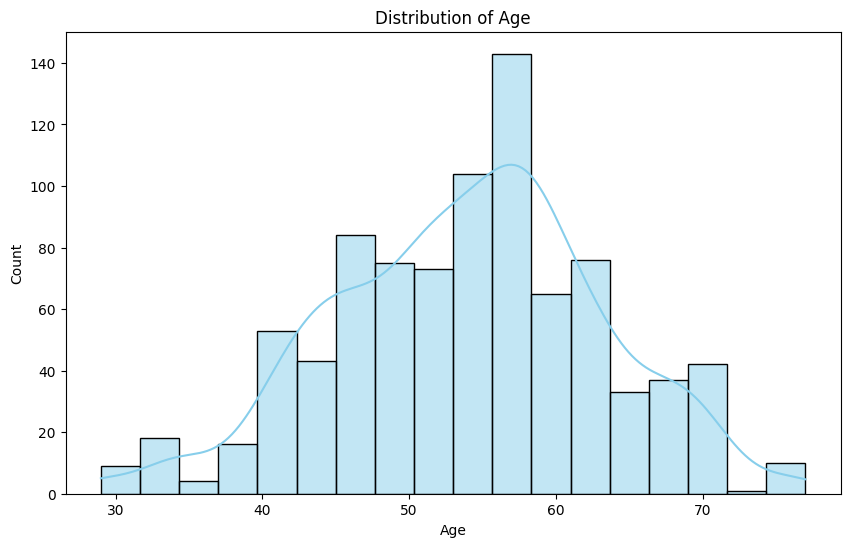

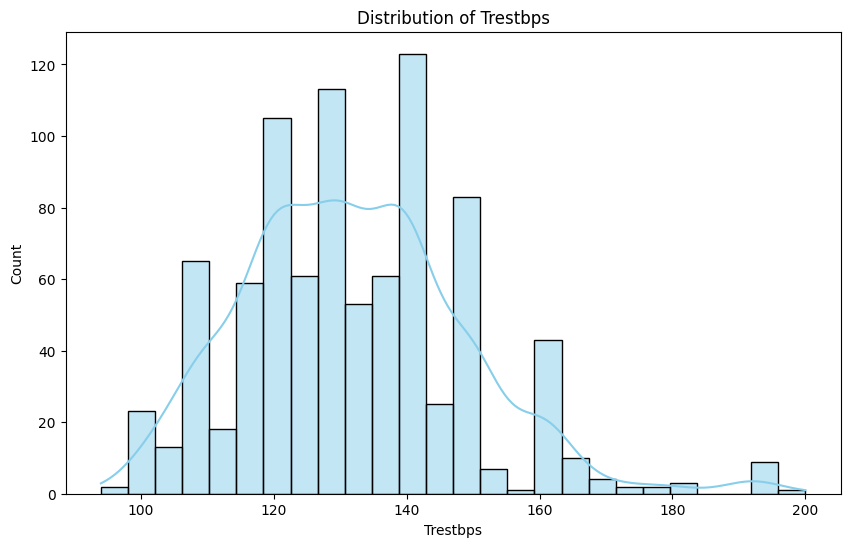

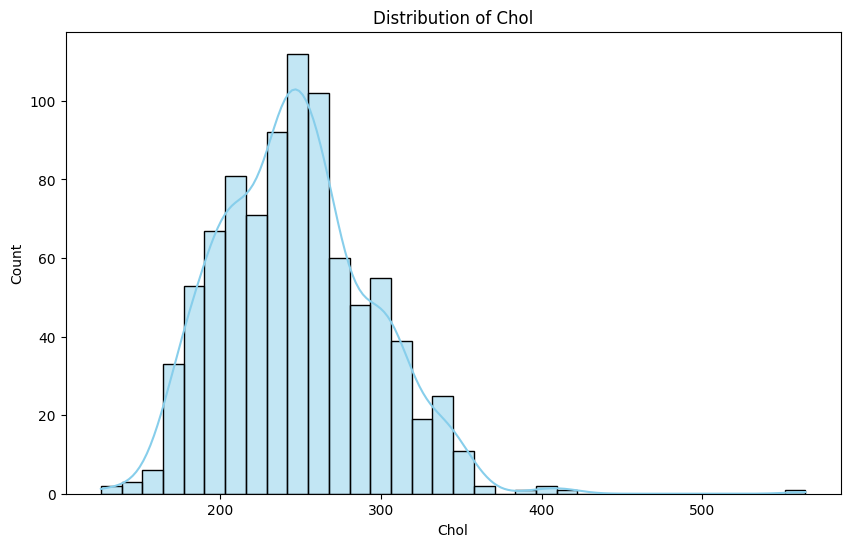

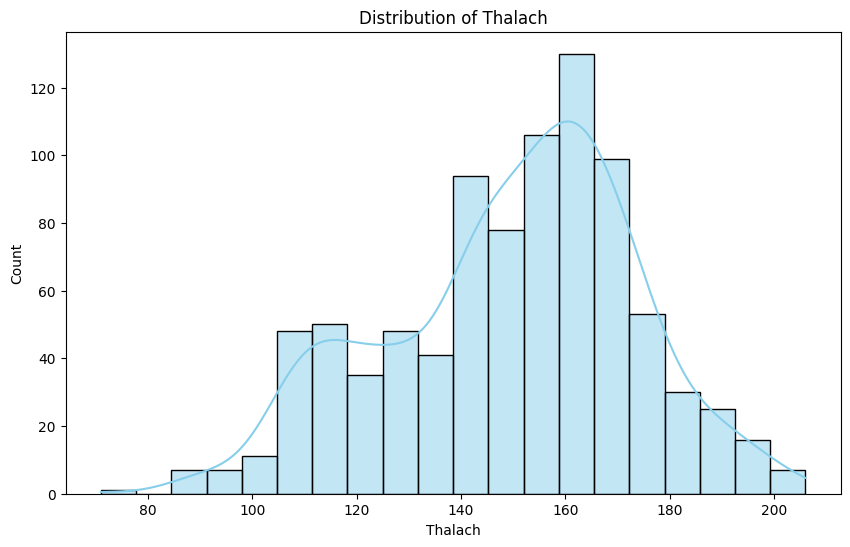

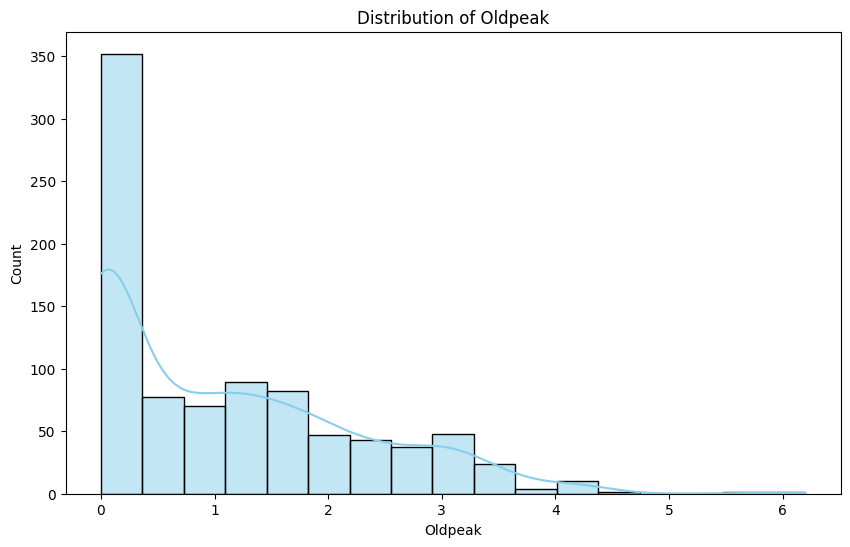

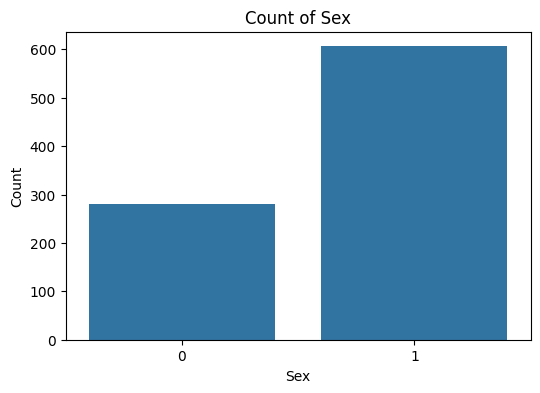

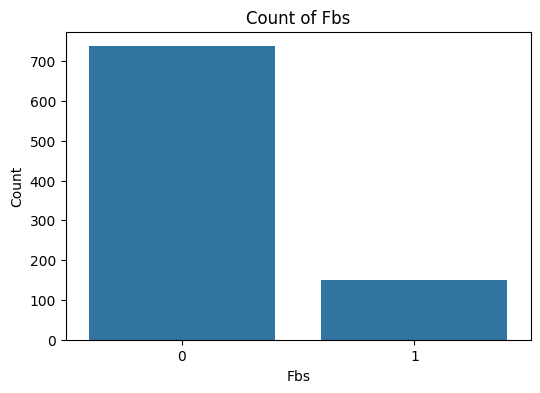

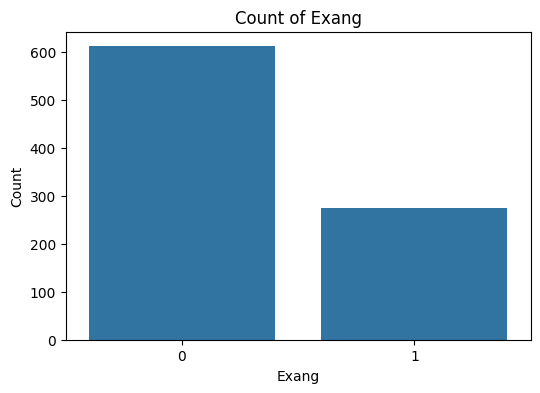

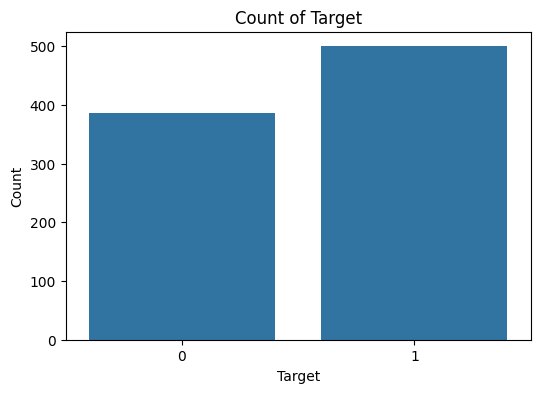

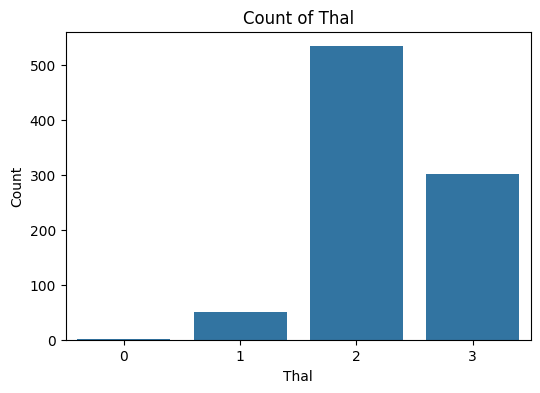

In [33]:
from matplotlib import pyplot as plt
import seaborn as sns

Columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df.hist(column=Columns, figsize=(20, 15))
non_binary_columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
for column in non_binary_columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[column], kde=True, color='skyblue')
    plt.title(f'Distribution of {column.capitalize()}')
    plt.xlabel(column.capitalize())
    plt.ylabel('Count')
    plt.show()
binary_columns = ['sex', 'fbs', 'exang', 'target', 'thal']
for column in binary_columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=df[column])
    plt.title(f'Count of {column.capitalize()}')
    plt.xlabel(column.capitalize())
    plt.ylabel('Count')
    plt.show()

## Preprocessing

In [31]:
def preprocessing_data(df):
    """
    Preprocess your data (eg. Drop null datapoints or fill missing data)
    :param df: pandas DataFrame
    :return: pandas DataFrame
    """
    # Todo: preprocess data
    df = df.dropna()  # Drop rows with missing values (if any)
    return df

In [32]:
df = preprocessing_data(df.copy())

## Feature Engineering

<Axes: >

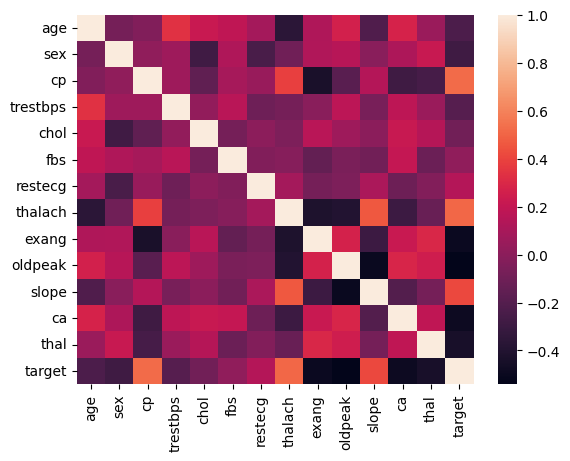

In [ ]:
# Heatmap
import seaborn as sns

def apply_feature_engineering(df):
    """
    Apply all feature engineering to transform your data into number
    :param df: pandas DataFrame
    :return: pandas DataFrame
    """
    # Todo: Normalize your data
    df = (df - df.min()) / (df.max() - df.min())
    return df

df = apply_feature_engineering(df)
sns.heatmap(df.corr()) # Show heatmap after normalized data

In [ ]:
def prepare_X_y(df):
    """
    Feature engineering and create X and y
    :param df: pandas dataframe
    :return: (X, y) output feature matrix (dataframe), target (series)
    """
    # Todo: Split data into X and y (using sklearn train_test_split). Return two dataframes
    X = # Todo: Select features
    y = # Todo: Select label
    return X, y

X, y = prepare_X_y(df)

SyntaxError: invalid syntax (2325553885.py, line 8)

# Apply machine learning model

## Train-test split

In [ ]:
from sklearn.model_selection import train_test_split
RANDOM_STATE = ??
TRAIN_SIZE = ??

trainX, testX ,trainY, testY = train_test_split(X, y, train_size=TRAIN_SIZE, random_state=RANDOM_STATE)

## Build SK-learn model

In [ ]:
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline

def build_model(X, y):
    """
    Design your model and train it (including your best params)
    :param X: feature matrix
    :param y: target
    :return: a model
    """

    # Todo: Input your scaler and logistic model into pipeline
    model = make_pipeline()
    # Todo: fit your model with X, y

    return model

def calculate_performance(y_true, y_pred):
    """

    :param y_true: ground truth values
    :param y_pred: predictions
    :return:
    """
    # Todo: return your error value like accuracy, f1score, ...
    print("precision", )
    print("recall", )
    print("accuracy", )
    print("F1", )

    # Todo: Only choose one of them as your score for the question 7
    main_score =
    return main_score

model = build_model(trainX, trainY)
# Compare on training dataset
pred = model.predict(testX)

In [ ]:
def get_conclusion():
    # Todo: Please return your answer, conclusion and opinion right here
    return "7. " \
           "Other conclusion: "